In [2]:
# this script was written to estimate the PSDs by using window lengths of 200 s and an overlap of 100 s
# PSDs are averged every 3600 s and saved
# instrument is removed afterwards
# cross-crrelations are also estimated every hour using the same window lengths
# same as before the instrument response is removed afterwards

import numpy as np
import scipy.io as sio
from scipy.io import savemat
import scipy.signal as sp
import matplotlib.pyplot as plt
import math as mt
import os.path as op
import obspy
import statistics as st
from obspy.core import read
from obspy.core.trace import Trace
from obspy.core.stream import Stream
from obspy import UTCDateTime
from obspy import read_inventory
from scipy.fft import fft, fftfreq
import datetime
from obspy.clients.filesystem.sds import Client

In [5]:
rootP2 = '/dcache/etseis/et/EMR/Data'
archiveP2 = Client(rootP2)

# read metadata inventory
respPath = '/dcache/etseis/et/EMR/Stations/NL.TERZ.xml'
invNow = read_inventory(respPath)

#azP2 = 220*2*np.pi/360;
azP2 = 0*2*np.pi/360;
azP3 = 0*2*np.pi/360;

# Analyzing January data from 2023
dateStVec = np.array([261])
yearVec = np.array([2022])
nDays = 1;

winLen = 800 # data extraction length
winOv = 400;
psdLen = 100;
psdOv = 50;
fSamp = 40;
winAvg = 800; # lets average the PSDs and cross-correlations every four hours
winSave = 86400 # and lets save the matrix of PSDs every day
winLenSamp = int(winLen*fSamp);

dayNow = int(dateStVec[0])
yearNow = yearVec[0]
A = datetime.datetime(yearNow,1,1)+datetime.timedelta(days=dayNow -1)
monthNow = A.month
monthDay = A.day
monthYear = A.year
dateUse = UTCDateTime(monthYear,monthNow,monthDay)

totSegAvg = int(np.floor((winAvg-winOv)/(winLen-winOv)));
totSeg = int(np.floor((86400-winOv)/(winLen-winOv)))
totSegSave = int(np.floor((86400-winOv)/(winLen-winOv)))

xf = fftfreq(psdLen*fSamp, 1/fSamp)[:((psdLen*fSamp)//2)]
f1 = 0.01; f2=15;
f1Ind = np.argmax(xf>=f1); f2Ind = np.argmax(xf>=f2);
fLen = f2Ind-f1Ind;
startDay = dateUse.julday

#fig, axs = plt.subplots(2, 2, figsize=(16,9))
# create the empty matrices for saving the output


for dayNo in range(0,nDays):
    psdZ0Daily = np.zeros((fLen,totSegSave))
    psdEW0Daily = np.zeros((fLen,totSegSave))
    psdNS0Daily = np.zeros((fLen,totSegSave))
    psdZ1Daily = np.zeros((fLen,totSegSave))
    psdEW1Daily = np.zeros((fLen,totSegSave))
    psdNS1Daily = np.zeros((fLen,totSegSave))

    saveCounter = 0;
    
    for i in range(0,totSeg):
    #for i in range(0,totSeg): # this runs for all the segments
        # check if it is the segment where averaging will stop
        Start = dateUse + i*(winLen-winOv) + (dayNo*86400);
        eTime = Start+winLen;
        dayNow = Start.julday
    
        if(dayNow>startDay):
            # new day
            print('Day '+ str(dayNow) + ' in progress' )
            startDay = dayNow
    
        #print('Reading streams')
        # stream of length winLen seconds
        #stTERZSurf = archive.get_waveforms(station='TERZ',channel='BHZ',network='NL',location='00',starttime= Start,endtime=eTime)
        stHHZ1 = archiveP2.get_waveforms(station='TERZ',channel='BHZ',network='NL',location='01',starttime= Start,endtime=eTime)
        stHHN1 = archiveP2.get_waveforms(station='TERZ',channel='BH1',network='NL',location='01',starttime= Start,endtime=eTime)
        stHHE1 = archiveP2.get_waveforms(station='TERZ',channel='BH2',network='NL',location='01',starttime= Start,endtime=eTime)
    
        #stCTSNSurf = archive.get_waveforms(station='CTSN',channel='BHZ',network='NL',location='00',starttime= Start,endtime=eTime)
        stHHZ0 = archiveP2.get_waveforms(station='TERZ',channel='BHZ',network='NL',location='00',starttime= Start,endtime=eTime)
        stHHN0 = archiveP2.get_waveforms(station='TERZ',channel='BHN',network='NL',location='00',starttime= Start,endtime=eTime)
        stHHE0 = archiveP2.get_waveforms(station='TERZ',channel='BHE',network='NL',location='00',starttime= Start,endtime=eTime)
    
        #print('Read all streams '+str(i))
        if(stHHZ1 and stHHN1 and stHHE1):
            trace = stHHN1[0];
            fSamp = trace.stats.sampling_rate;
            decFactor = 2;
            #trace.decimate(decFactor);
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            trace.attach_response(invNow)
            trace.remove_response(inventory=invNow,output='VEL',zero_mean=True,hide_sensitivity_mismatch_warning=True)
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            dataHHN1 = trace.data;
        
            trace = stHHE1[0];
            fSamp = trace.stats.sampling_rate;
            decFactor = 2;
            #trace.decimate(decFactor);
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            trace.attach_response(invNow)
            trace.remove_response(inventory=invNow,output='VEL',zero_mean=True,hide_sensitivity_mismatch_warning=True)
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            dataHHE1 = trace.data;
       
            # apply the rotation
            dataNSNew = dataHHN1[0:winLenSamp]*np.cos(azP2) + dataHHE1[0:winLenSamp]*np.sin(azP2)
            dataEWNew = -dataHHN1[0:winLenSamp]*np.sin(azP2) + dataHHE1[0:winLenSamp]*np.cos(azP2)
        
            trace = stHHZ1[0];
            fSamp = trace.stats.sampling_rate;
            decFactor = 2;
            #trace.decimate(decFactor);
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            trace.attach_response(invNow)
            trace.remove_response(inventory=invNow,output='VEL',zero_mean=True,hide_sensitivity_mismatch_warning=True)
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            dataHHZ1 = trace.data;
        
            f2,psdNowHHZ1 = sp.welch(dataHHZ1, fs=fSamp, window='hann', nperseg=psdLen*fSamp, noverlap=psdOv*fSamp, nfft=psdLen*fSamp, detrend='linear')
            f2,psdNowHHN1 = sp.welch(dataNSNew, fs=fSamp, window='hann', nperseg=psdLen*fSamp, noverlap=psdOv*fSamp, nfft=psdLen*fSamp, detrend='linear')
            f2,psdNowHHE1 = sp.welch(dataEWNew, fs=fSamp, window='hann', nperseg=psdLen*fSamp, noverlap=psdOv*fSamp, nfft=psdLen*fSamp, detrend='linear')
            # do ffts for cross-correlations
        
            psdZ1Daily[:,saveCounter] = psdZ1Daily[:,saveCounter]+psdNowHHZ1[f1Ind:f2Ind]
            psdNS1Daily[:,saveCounter] = psdNS1Daily[:,saveCounter]+psdNowHHN1[f1Ind:f2Ind]
            psdEW1Daily[:,saveCounter] = psdEW1Daily[:,saveCounter]+psdNowHHE1[f1Ind:f2Ind]
        
        else:
            print('Borehole has insufficient data')
            goodP2 = 0;
        
        # good for surface data
        if(stHHZ0 and stHHN0 and stHHE0):
            trace = stHHN0[0];
            fSamp = trace.stats.sampling_rate;
            decFactor = 2;
            #trace.decimate(decFactor);
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            trace.attach_response(invNow)
            trace.remove_response(inventory=invNow,output='VEL',zero_mean=True,hide_sensitivity_mismatch_warning=True)
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            dataHHN0 = trace.data;
        
            trace = stHHE0[0];
            fSamp = trace.stats.sampling_rate;
            decFactor = 2;
            #trace.decimate(decFactor);
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            trace.attach_response(invNow)
            trace.remove_response(inventory=invNow,output='VEL',zero_mean=True,hide_sensitivity_mismatch_warning=True)
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            dataHHE0 = trace.data;
        
            trace = stHHZ0[0];
            fSamp = trace.stats.sampling_rate;
            decFactor = 2;
            #trace.decimate(decFactor);
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            trace.attach_response(invNow)
            trace.remove_response(inventory=invNow,output='VEL',zero_mean=True,hide_sensitivity_mismatch_warning=True)
            trace.trim(starttime=Start, endtime=eTime, pad=True, fill_value=0)
            dataHHZ0 = trace.data;
        
            f2,psdNowHHZ0 = sp.welch(dataHHZ0, fs=fSamp, window='hann', nperseg=psdLen*fSamp, noverlap=psdOv*fSamp, nfft=psdLen*fSamp, detrend='linear')
            f2,psdNowHHN0 = sp.welch(dataHHN0, fs=fSamp, window='hann', nperseg=psdLen*fSamp, noverlap=psdOv*fSamp, nfft=psdLen*fSamp, detrend='linear')
            f2,psdNowHHE0 = sp.welch(dataHHE0, fs=fSamp, window='hann', nperseg=psdLen*fSamp, noverlap=psdOv*fSamp, nfft=psdLen*fSamp, detrend='linear')
            # do ffts for cross-correlations
        
            psdZ0Daily[:,saveCounter] = psdZ0Daily[:,saveCounter]+psdNowHHZ0[f1Ind:f2Ind]
            psdNS0Daily[:,saveCounter] = psdNS0Daily[:,saveCounter]+psdNowHHN0[f1Ind:f2Ind]
            psdEW0Daily[:,saveCounter] = psdEW0Daily[:,saveCounter]+psdNowHHE0[f1Ind:f2Ind]
        
        else:
            print('Surface has insufficient data')
            goodP2 = 0;
        # reset other quantities
        saveCounter = saveCounter+1

    totMatFilePathHRBSZ1 = '/data/gravwav/koley/HRBS/AllPSD/NoScale/2022/TERZZ1Day'+ str(dayNow) + '.mat'
    totMatFilePathHRBSNS1 = '/data/gravwav/koley/HRBS/AllPSD/NoScale/2022/TERZNS1Day'+ str(dayNow) + '.mat'
    totMatFilePathHRBSEW1 = '/data/gravwav/koley/HRBS/AllPSD/NoScale/2022/TERZEW1Day'+ str(dayNow) + '.mat'

    totMatFilePathHRBSZ0 = '/data/gravwav/koley/HRBS/AllPSD/NoScale/2022/TERZZ0Day'+ str(dayNow) + '.mat'
    totMatFilePathHRBSNS0 = '/data/gravwav/koley/HRBS/AllPSD/NoScale/2022/TERZNS0Day'+ str(dayNow) + '.mat'
    totMatFilePathHRBSEW0 = '/data/gravwav/koley/HRBS/AllPSD/NoScale/2022/TERZEW0Day'+ str(dayNow) + '.mat'

    sio.savemat(totMatFilePathHRBSZ1,mdict={'freq':f2,'psdDailyZ1':psdZ1Daily})
    sio.savemat(totMatFilePathHRBSNS1,mdict={'freq':f2,'psdDailyNS1':psdNS1Daily})
    sio.savemat(totMatFilePathHRBSEW1,mdict={'freq':f2,'psdDailyEW1':psdEW1Daily})
    sio.savemat(totMatFilePathHRBSZ0,mdict={'freq':f2,'psdDailyZ0':psdZ0Daily})
    sio.savemat(totMatFilePathHRBSNS0,mdict={'freq':f2,'psdDailyNS0':psdNS0Daily})
    sio.savemat(totMatFilePathHRBSEW0,mdict={'freq':f2,'psdDailyEW0':psdEW0Daily})


/data/gravwav/koley/my_venv/lib/python3.10/site-packages/obspy/io/stationxml/core.py:91: UserWarning: The StationXML file has version 1.2, ObsPy can read versions (1.0, 1.1). Proceed with caution.
  warnings.warn("The StationXML file has version %s, ObsPy can "


Text(0.5, 1.0, 'Jan27, 2025 - Latest')

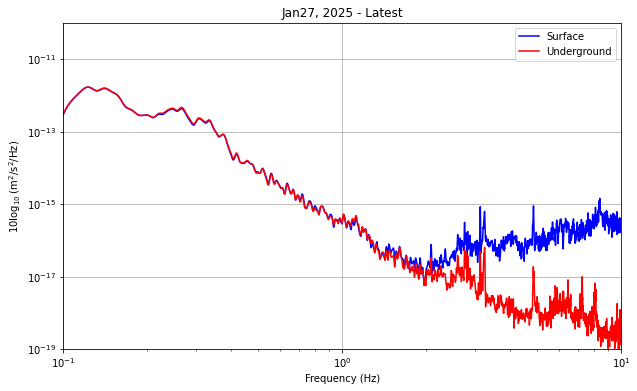

In [7]:
plt.figure(figsize=(10,6))
plt.loglog(f2[f1Ind:f2Ind],psdZ0Daily[:,10],'b',label='Surface')
plt.loglog(f2[f1Ind:f2Ind],psdZ1Daily[:,10],'r',label='Underground')
plt.xlim(0.1,10)
plt.ylim(10**-19,10**-10)
plt.ylabel(r'$10 \log_{10} \; \left( \mathrm{m}^2/\mathrm{s}^2/\mathrm{Hz} \right)$')
plt.xlabel('Frequency (Hz)')
plt.legend()
plt.grid()
plt.title('Jan27, 2025 - Latest')